In [138]:
#Monthly Job Postings for Top Data Jobs in the US
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


In [139]:
df_PH = df[df['job_country']== 'Philippines'].copy()
df_PH['job_posted_month'] = df_PH['job_posted_date'].dt.strftime('%B')
df_PH_pivot = df_PH.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

In [ ]:
#reset index
df_PH_pivot.reset_index(inplace=True)
df_PH_pivot

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
0,April,177,26,333,144,104,8,52,26,18,67
1,August,154,24,438,198,136,15,53,28,16,52
2,December,91,5,288,89,94,7,23,17,17,29
3,February,157,28,374,189,89,14,53,32,14,67
4,January,175,27,757,334,220,11,81,53,29,117
5,July,148,16,409,148,97,6,46,21,19,35
6,June,136,8,388,171,97,9,45,24,11,15
7,March,157,19,359,166,87,7,37,19,13,38
8,May,104,8,311,112,85,11,28,18,15,31
9,November,135,11,391,141,117,16,41,17,22,31


In [ ]:
df_PH_pivot['month_no'] = pd.to_datetime(df_PH_pivot['job_posted_month'], format='%B').dt.month
df_PH_pivot.sort_values('month_no', inplace=True)
df_PH_pivot.set_index('job_posted_month', inplace=True)

KeyError: 'job_posted_month'

<Axes: xlabel='job_posted_month'>

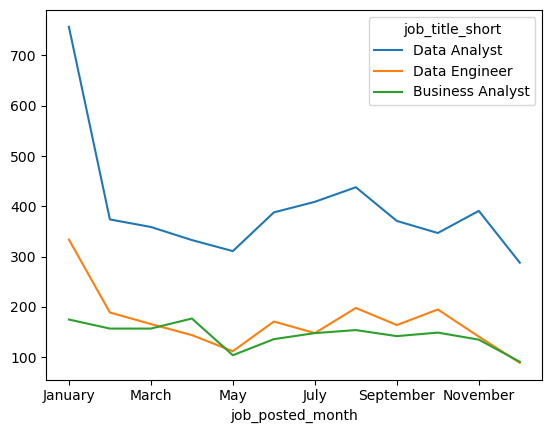

In [ ]:
#top 3 data job in the Philippines
top3_ph = df_PH['job_title_short'].value_counts().head(3)
top3_ph = top3_ph.index.to_list()
df_PH_pivot[top3_ph].plot(kind = 'line')

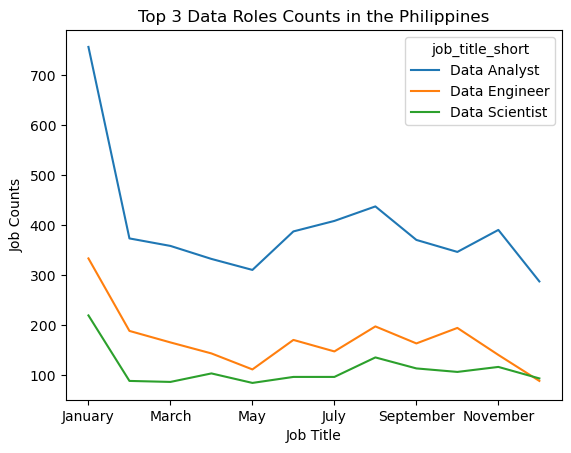

In [178]:
#count of top 3 data job overall in the Philippines
top3_world = df['job_title_short'].value_counts().head(3)
top3_world = top3_world.index.to_list()
df_PH_pivot[top3_world].plot(kind='line')
plt.xlabel('Job Title')
plt.ylabel('Job Counts')
plt.title('Top 3 Data Roles Counts in the Philippines')
plt.show()
#Data Scientist role in the philippines is not that popular. The reason needs more investigation. The same goes to why data analyst role is super in-demand during January.
#Might consider time series analysis (idk why, actually xdd)


NoneType